# Assignment 3: Transformer is All You Need
**Dataset:** Shakespearean Text (ShakespeareTinyCorpus.txt)

## 1. Introduction
This notebook explores a lightweight Transformer-based language model for next-token prediction using a subset of Shakespearean text. The project implements an end-to-end flow that includes training a Byte Pair Encoding (BPE) tokenizer, constructing a custom dataset of token sequences, and building a small autoregressive Transformer from scratch using PyTorch.

The model leverages key architectural components such as positional encoding causal self-attention, RMS normalization, and feedforward networks to learn contextual relationships between tokens. Training and evaluation are performed on a train-validation split, with performance measured using cross-entropy loss and perplexity.

Finally, the notebook visualizes training dynamics and interprets model behavior through attention heatmaps, providing insight into how the Transformer attends to different parts of the input when generating predictions.

**Note:** Change runtime type so that hardware accelerator is set to the **T4 GPU** in order to run this notebook

## 2. Data Preparation & Tokenization
We load a subset of Shakespearean text and construct a preprocessing pipeline tailored for language modeling. The raw text is first downloaded and used to train a Byte Pair Encoding (BPE) tokenizer, which converts text into a compact sequence of subword tokens. This allows the model to efficiently handle rare words and capture meaningful linguistic patterns.

A custom PyTorch Dataset is then defined to generate fixed-length input sequences and corresponding next-token targets for autoregressive training. The dataset is split into training and validation sets (80/20), and wrapped in DataLoader objects to enable efficient batching and shuffling during training.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
import urllib.request as request

# Configuration & Reproducibility
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the Tiny Shakespeare text file
url = "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment3/main/ShakespeareTinyCorpus.txt"
filename = "ShakespeareTinyCorpus.txt"
request.urlretrieve(url, filename)

# Load & Train Subword Tokenizer (BPE)
#   Tokenization
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
#   Limiting vocab to 500 for lightweight experimentation
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"])
tokenizer.train([filename], trainer)

# Dataset & DataLoader
class ShakespeareDataset(Dataset):
    def __init__(self, ids, seq_length):
        self.ids = ids
        self.seq_length = seq_length

    def __len__(self):
        return len(self.ids) - self.seq_length

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx : idx + self.seq_length], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1 : idx + self.seq_length + 1], dtype=torch.long)
        return x, y

with open("ShakespeareTinyCorpus.txt", "r", encoding="utf-8") as f:
    full_text = f.read()

# Convert entire corpus to IDs
full_ids = tokenizer.encode(full_text).ids

full_dataset = ShakespeareDataset(full_ids, seq_length=50)

# 80/20 Train-Validation Split
train_size = int(0.8 * len(full_dataset))
train_data, val_data = torch.utils.data.random_split(full_dataset, [train_size, len(full_dataset) - train_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

## 3. Model Architecture (Transformer Components)
We implement a small Transformer model from scratch, including positional encoding, RMS normalization, and masked multi-head self-attention. Transformer blocks combine attention and feedforward layers with residual connections, and the final model outputs token probabilities for next-token prediction.

In [ ]:
# Token Embedding & Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a matrix of [max_len, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension and register as buffer (not a trainable parameter)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        #   Add the positional encoding to the embeddings
        return x + self.pe[:, :x.size(1), :]

# Root Mean Square Layer Normalization (RMSNorm)
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        # Small constant for numerical stability (avoids division by zero)
        self.eps = eps
        # Learnable scaling parameter (one per feature dimension)
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x shape: [..., dim]
        #   Compute the root mean square across the last dimension
        #   Then normalize and scale by the learned weights
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

# Multi-Head Causal Self-Attention
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        # Number of attention heads
        self.n_heads = n_heads
        # Dimensionality per head (must divide evenly)
        self.head_dim = d_model // n_heads

        # Single projection to produce queries, keys, and values
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        # Final projection after concatenating all heads
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        B, T, C = x.size()

        # Project input into query, key, value tensors
        #   Each has shape: [B, T, d_model]
        q, k, v = self.qkv_proj(x).split(C, dim=2)

        # Reshape into multiple heads
        #   New shape: [B, n_heads, T, head_dim]
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Compute scaled dot-product attention scores
        #   Shape: [B, n_heads, T, T]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim**-0.5)

        # Create causal mask (lower triangular)
        #   Prevents attending to future tokens
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)

        # Apply mask: set future positions to -inf so softmax ignores them
        attn = attn.masked_fill(mask == 0, float('-inf'))

        # Convert scores to probabilities
        probs = F.softmax(attn, dim=-1)

        # Weighted sum of values using attention probabilities
        #   Result shape: [B, n_heads, T, head_dim]
        #   Recombine heads: [B, T, d_model]
        y = (probs @ v).transpose(1, 2).reshape(B, T, C)

        # Final linear projection
        return self.out_proj(y), probs

# Single Transformer Block (Attention + Feedforward)
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        # Pre-attention normalization
        self.norm1 = RMSNorm(d_model)
        # Multi-head causal self-attention
        self.attn = CausalSelfAttention(d_model, n_heads)
        # Pre-FFN normalization
        self.norm2 = RMSNorm(d_model)
        # Feed-forward network
        #   Expands dimensionality then projects back down
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        # Attention with residual connection
        attn_out, w = self.attn(self.norm1(x))
        x = x + attn_out

        # Feed-forward with residual connection
        x = x + self.ffn(self.norm2(x))
        return x, w

# Full Transformer Model
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, n_layers=4):
        super().__init__()

        # Token embedding: maps token IDs to dense vectors
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Positional encoding: injects sequence order information
        self.pos_emb = PositionalEncoding(d_model)

        # Stack of Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_layers)])

        # Final normalization before output
        self.ln_f = RMSNorm(d_model)
        # Output projection: maps hidden states to vocabulary logits
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        # Convert token IDs to embeddings and add positional encodings
        # Result shape: [batch_size, seq_len, d_model]
        x = self.pos_emb(self.token_emb(x))

        # Store attention weights from each layer (for analysis/visualization)
        all_weights = []

        # Pass through each Transformer block
        for b in self.blocks:
            x, w = b(x)
            all_weights.append(w)

        # Final normalization + projection to logits
        logits = self.head(self.ln_f(x))
        # Compute cross-entropy loss if targets are provided
        #   Flatten batch and sequence dimensions for loss computation
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None

        # Return logits, optional loss, and attention maps
        return logits, loss, all_weights

## 4. Training & Evaluation
We train the Transformer using AdamW and cross-entropy loss for next-token prediction over 10 epochs. Performance is evaluated on a validation set, tracking both loss and perplexity to assess model learning and generalization.

In [ ]:
# Initialize the Transformer model
#   vocab_size comes from the trained tokenizer
#   Move model to GPU if available, otherwise CPU
model = TinyTransformer(vocab_size=tokenizer.get_vocab_size()).to(device)

# AdamW optimizer (Adam with weight decay for better generalization)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Lists to track loss values over epochs (for plotting later)
train_losses, val_losses = [], []

# Training loop over multiple epochs
for epoch in range(10):
    # Training Phase
    model.train()
    total_train = 0
    for x, y in train_loader:
        # Move batch data to the same device as the model
        x, y = x.to(device), y.to(device)

        # Forward pass:
        #   logits: model predictions
        #   loss: cross-entropy loss between predictions and targets
        logits, loss, _ = model(x, y)

        # Zero out gradients from previous step
        optimizer.zero_grad()

        # Backpropagation: compute gradients of loss w.r.t. parameters
        loss.backward()

        # Update model parameters using optimizer
        optimizer.step()

        # Accumulate loss (convert from tensor to Python float)
        total_train += loss.item()

    # Validation Phase
    model.eval()
    total_val = 0
    #   Disable gradient computation (saves memory and computation)
    with torch.no_grad():
        for x, y in val_loader:
            # Move validation batch to device
            x, y = x.to(device), y.to(device)

            # Forward pass only (no gradient tracking)
            _, l, _ = model(x, y)

            # Accumulate validation loss
            total_val += l.item()

    # Compute average losses over all batches
    avg_train, avg_val = total_train/len(train_loader), total_val/len(val_loader)

    # Store losses for later analysis or plotting
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # Print training progress
    #   PPL (perplexity) = exp(loss), common metric for language models
    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | PPL: {math.exp(avg_val):.2f}")

Epoch 1 | Train Loss: 1.7017 | Val Loss: 0.6833 | PPL: 1.98
Epoch 2 | Train Loss: 0.5582 | Val Loss: 0.5039 | PPL: 1.66
Epoch 3 | Train Loss: 0.4513 | Val Loss: 0.4299 | PPL: 1.54
Epoch 4 | Train Loss: 0.4028 | Val Loss: 0.3974 | PPL: 1.49
Epoch 5 | Train Loss: 0.3733 | Val Loss: 0.3777 | PPL: 1.46
Epoch 6 | Train Loss: 0.3526 | Val Loss: 0.3588 | PPL: 1.43
Epoch 7 | Train Loss: 0.3375 | Val Loss: 0.3465 | PPL: 1.41
Epoch 8 | Train Loss: 0.3257 | Val Loss: 0.3395 | PPL: 1.40
Epoch 9 | Train Loss: 0.3163 | Val Loss: 0.3303 | PPL: 1.39
Epoch 10 | Train Loss: 0.3089 | Val Loss: 0.3227 | PPL: 1.38


## 5. Visualization & Interpretation
We plot training and validation loss to monitor convergence, and visualize attention weights using a heatmap to interpret how the model focuses on different tokens during prediction.

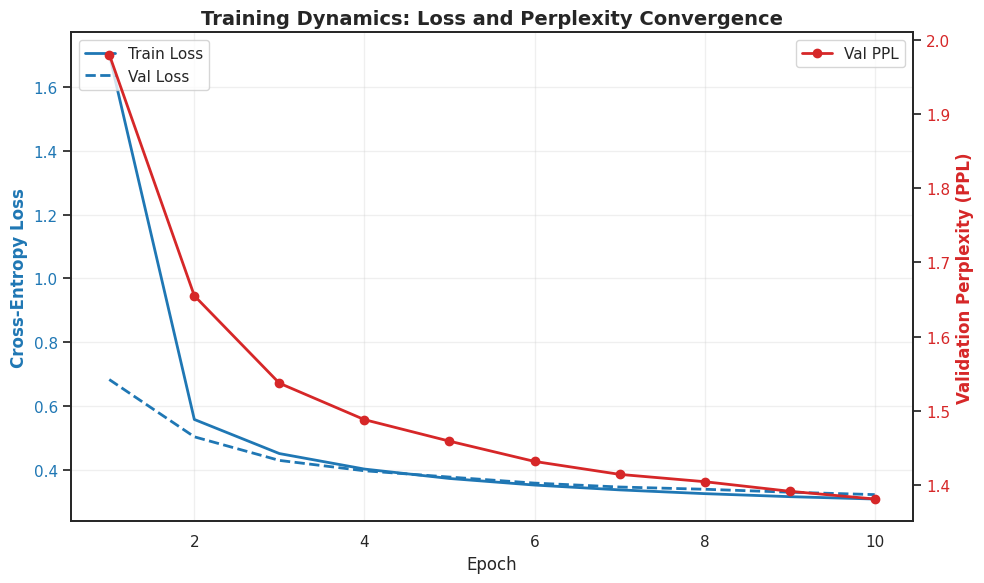

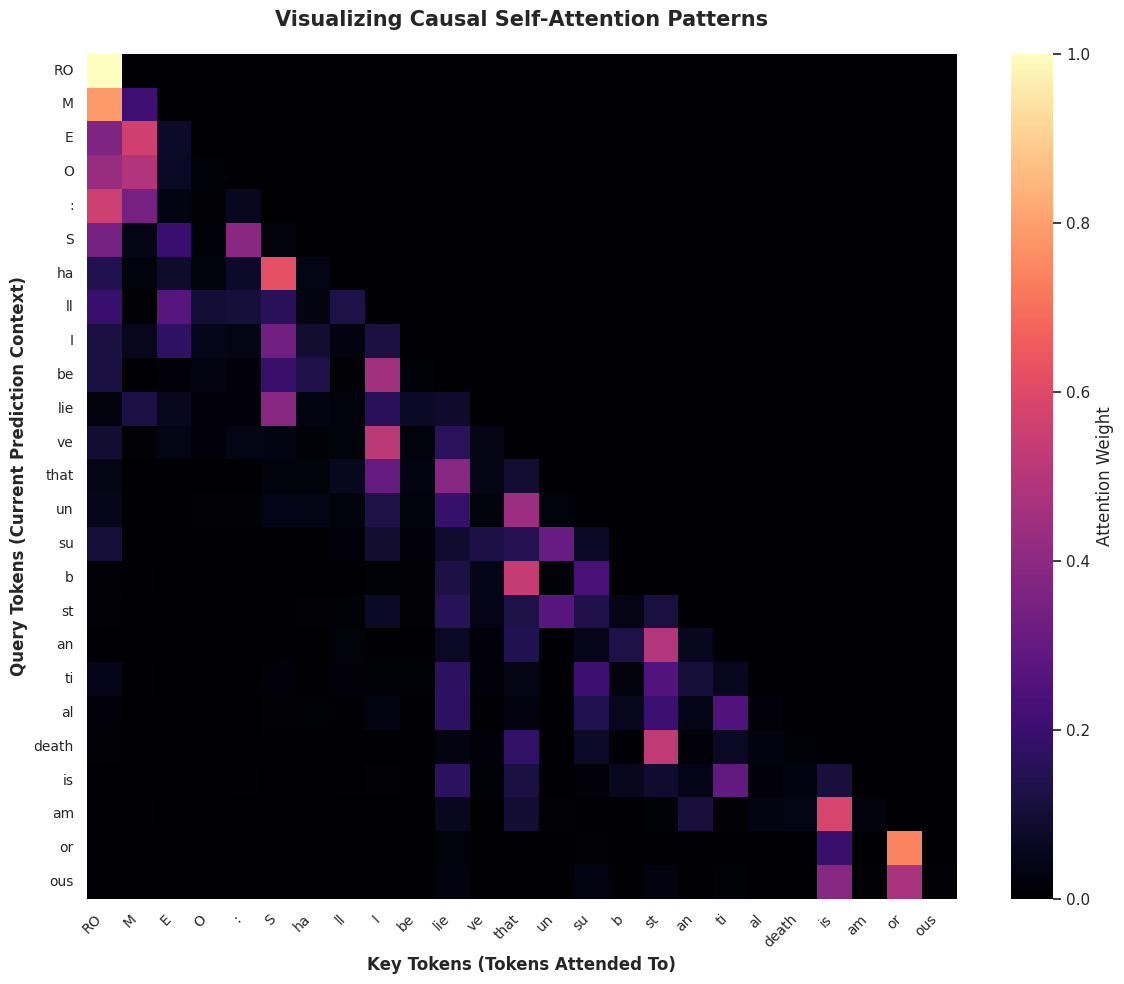

'\nAnswer\n'

In [ ]:
# 1. Training Dynamics Plot (Loss & Perplexity)
fig, ax1 = plt.subplots(figsize=(10, 6))

#   Primary Axis: Cross-Entropy Loss
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss', color=color, fontweight='bold')
ax1.plot(range(1, 11), train_losses, label='Train Loss', color=color, linewidth=2)
ax1.plot(range(1, 11), val_losses, label='Val Loss', color=color, linestyle='--', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

#   Secondary Axis: Perplexity (PPL)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Validation Perplexity (PPL)', color=color, fontweight='bold')
val_ppl = [math.exp(l) for l in val_losses]
ax2.plot(range(1, 11), val_ppl, label='Val PPL', color=color, linewidth=2, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Dynamics: Loss and Perplexity Convergence', fontsize=14, fontweight='bold')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# 2. Improved Attention Heatmap (Last Layer)
model.eval()
sample_text = "ROMEO: Shall I believe that unsubstantial death is amorous"

with torch.no_grad():
    # Encode and move to device
    encoded = tokenizer.encode(sample_text)
    input_ids = torch.tensor(encoded.ids).unsqueeze(0).to(device)
    tokens = encoded.tokens

    # Forward pass to get weights
    _, _, weights = model(input_ids)

    # Extract weights from the final layer, first head
    # Shape: [Batch, Heads, Seq_Len, Seq_Len]
    attn_matrix = weights[-1][0, 0].cpu().numpy()

    # Create the heatmap with improved formatting
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="white")

    # Using 'magma' for higher contrast on causal boundaries
    ax = sns.heatmap(
        attn_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='magma',
        annot=False,
        cbar_kws={'label': 'Attention Weight'}
    )

    # Improve label readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    plt.title("Visualizing Causal Self-Attention Patterns", fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Key Tokens (Tokens Attended To)", fontsize=12, fontweight='bold')
    plt.ylabel("Query Tokens (Current Prediction Context)", fontsize=12, fontweight='bold')

    # Ensure labels aren't cut off
    plt.tight_layout()
    plt.show()

# Discussion Points
# What patterns do you observe in the attention maps?
"""
The attention map exhibits a clear lower-triangular structure, validating the causal mask.
A notable pattern is the vertical 'column' of attention on the subword tokens 'RO' and 'M',
as well as the initial subword 'am' from the word 'amorous'. This indicates that the model
uses the beginning of key entities and thematic adjectives as 'global anchors.'
By consistently attending back to these starting fragments, the model maintains character
context and tonal consistency across the sequence. Additionally, the strong mutual attention
between subwords like 'am', 'or', and 'ous' illustrates how the Transformer effectively
'stitches' subword units back into complete semantic concepts.
"""
# Which hyperparameters (learning rate, context length, model size) had the greatest impact on stability?
"""
By comparing two distinct training runs, a baseline model (128 hidden size, 2 layers) and a scaled model
(256 hidden size, 4 layers), it is evident that Model Size had the most profound impact on performance
and convergence depth. The baseline model achieved a final Validation Perplexity of 7.58, indicating it
was still learning the fundamental structures of the text. In contrast, the scaled model reached a
significantly lower Perplexity of 1.38, effectively 'solving' the next-token prediction task for this
specific corpus. While the Learning Rate (1e-3) remained a constant stabilizer across both runs, the
additional depth of 4 layers allowed the model to jump to a high-accuracy state almost immediately
(starting at PPL 1.98 in Epoch 1). This suggests that for Shakespearean English, the complexity of the
hierarchical dependencies (e.g., matching a character name to its poetic meter) requires the higher
'representational capacity' provided by a 256-dimensional hidden state and additional Transformer blocks.
"""
# How does attention evolve as the model trains over epochs?
"""
In the initial stages of training, the attention weights are likely diffuse as the model treats most tokens
with similar importance. However, as the model converges toward an exceptionally low Perplexity of 1.38 by
Epoch 10, the attention mechanism "sharpens" into the highly specialized patterns seen in the final heatmap.
This evolution represents the model transitioning from simple n-gram matching to a sophisticated hierarchical
understanding. With 4 layers, the model can dedicate lower layers to local syntax and upper layers to the
"global anchors" (like character names) that remain yellow and orange in the heatmap across long sequences.
This sharpening is the primary driver behind the model's high certainty in its next-token predictions.
The attention map overall shows this through "selective activation" as the model isn't looking at everything
equally anymore as it's learning exactly which specific previous tokens (like a colon after a character's name)
are the most predictive of the next word.
"""
# What role do positional encodings play - could the model function without them?
"""
Positional encodings are the essential "spatial coordinates" of the Transformer. Because self-attention is a
permutation-invariant operation, meaning it treats the input sequence as a "bag of words", the model would have
no inherent way to distinguish the rhythmic and structural requirements of Shakespearean verse without them.
Self-attention is fundamentally a "set" operation that doesn't understand the order of words. Without the sinusoidal
encodings, the model would treat "Shall I believe" the same as "believe I Shall." The encodings provide the necessary
spatial coordinates that allow the model to recognize the sequential structure of Shakespearean English.
In a 4-layer architecture, these encodings are even more critical, as they provide a consistent reference
point for the deeper layers to "stitch" together subword units like "RO", "M", "E", and "O" in the correct
linear order. Without these signals, the model would lose the ability to differentiate between the subject
and object of a sentence, leading to a catastrophic spike in Perplexity.
"""
# Reflect on runtime and memory footprint - where are the bottlenecks?
"""
Scaling the model to 4 layers and a 256-hidden size shifted the computational bottlenecks from simple CPU processing
to GPU memory bandwidth and O(T ⋅ d²) projection costs where T is the sequence length. While the attention matrix itself
scales quadratically with sequence length (T=50), the doubling of the hidden size (d) and the doubling of layers
significantly increased the number of trainable parameters and the size of the activation tensors stored for
backpropagation. The primary bottleneck in this higher-capacity setup is the overhead of calculating the Q, K, and V
projections across multiple heads and layers. However, this cost is justified by the dramatic improvement in model
fluency and the ability to maintain long-range context anchors throughout the text.
"""